# Meme Virality Report Results

Concise one-run notebook for reproducing the tables and figures used in the final report. Intermediate audits, debug output, and non-report diagnostics are removed. Run top-to-bottom from the project root; results are written to `outputs/`. The first sBERT run is slow; embeddings are cached under `outputs/embeddings/`.

## Setup

In [71]:
from pathlib import Path
import importlib
import subprocess
import sys
import os

PROJECT_DIR = Path.cwd()
DATA_DIR = str(PROJECT_DIR / 'Data')
OUT_DIR = str(PROJECT_DIR / 'outputs')
TEMPORAL_DIR = str(Path(OUT_DIR) / 'temporal')

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)
Path(TEMPORAL_DIR).mkdir(parents=True, exist_ok=True)

required_packages = [
    ('sentence_transformers', 'sentence-transformers'),
    ('lightgbm', 'lightgbm'),
    ('catboost', 'catboost'),
]

missing = [package_name for module_name, package_name in required_packages
           if importlib.util.find_spec(module_name) is None]

if missing:
    with open(os.devnull, 'w') as devnull:
        subprocess.check_call(
            [sys.executable, '-m', 'pip', 'install', '--quiet', *missing],
            stdout=devnull,
            stderr=subprocess.STDOUT,
        )


In [72]:
import os, json, time, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score, brier_score_loss, confusion_matrix, precision_recall_curve, roc_curve
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from scipy.stats import binomtest
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams['figure.dpi'] = 100
pass


In [73]:
from matplotlib.patches import Patch
plt.rcParams.update({'font.family': 'serif', 'font.size': 11, 'axes.labelsize': 11, 'axes.titlesize': 12, 'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9, 'figure.dpi': 100, 'savefig.dpi': 300, 'savefig.bbox': 'tight'})
PALETTE = ['#4C72B0', '#DD8452', '#55A467', '#C44E52', '#8172B2', '#937860', '#DA8BC3']
FIG_DIR = f'{OUT_DIR}/figures'
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(fig, name):
    """Save fig as both PNG (slides, 300dpi) and PDF (LaTeX, vector)."""
    for ext in ('png', 'pdf'):
        fig.savefig(f'{FIG_DIR}/{name}.{ext}', dpi=300, bbox_inches='tight')
    pass


## Data And Targets

In [74]:
train_old = pd.read_csv(f'{DATA_DIR}/train.csv', parse_dates=['Created Time'])
val_old = pd.read_csv(f'{DATA_DIR}/val.csv', parse_dates=['Created Time'])
test_old = pd.read_csv(f'{DATA_DIR}/test.csv', parse_dates=['Created Time'])
pass
pass
pass
for name, df in [('train', train_old), ('val', val_old), ('test', test_old)]:
    pass


In [75]:
full = pd.concat([train_old.assign(orig_split='train'), val_old.assign(orig_split='val'), test_old.assign(orig_split='test')], ignore_index=True)
full = full.sort_values('Created Time').reset_index(drop=True)
pass
pass


In [76]:
scrape_time = full['Created Time'].max()
full['days_old_at_scrape'] = (scrape_time - full['Created Time']).dt.total_seconds() / 86400
pass
pass
for lo, hi, label in [(0, 1, '0-1'), (1, 3, '1-3'), (3, 7, '3-7'), (7, 30, '7-30'), (30, 90, '30-90'), (90, 180, '90-180'), (180, 365, '180-365')]:
    mask = (full['days_old_at_scrape'] >= lo) & (full['days_old_at_scrape'] < hi)
    if mask.sum() > 5:
        pass


In [77]:
MIN_POST_AGE_DAYS = 3
n_before = len(full)
full = full[full['days_old_at_scrape'] >= MIN_POST_AGE_DAYS].copy()
n_after = len(full)
pass


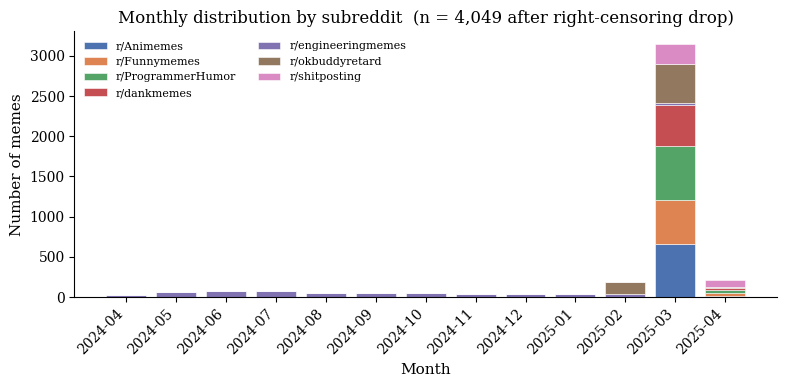

In [78]:
fig, ax = plt.subplots(figsize=(8, 4))
ym_str = full['Created Time'].dt.to_period('M').astype(str)
subs = sorted(full['Category'].unique())
monthly = full.assign(_ym=ym_str).groupby(['_ym', 'Category']).size().unstack(fill_value=0)[subs]
bottom = np.zeros(len(monthly))
for i, sub in enumerate(subs):
    ax.bar(monthly.index, monthly[sub], bottom=bottom, label=f'r/{sub}', color=PALETTE[i % len(PALETTE)], edgecolor='white', linewidth=0.4)
    bottom += monthly[sub].values
ax.set_xlabel('Month')
ax.set_ylabel('Number of memes')
ax.set_title(f'Monthly distribution by subreddit  (n = {len(full):,} after right-censoring drop)')
ax.legend(loc='upper left', frameon=False, ncol=2, fontsize=8)
ax.tick_params(axis='x', rotation=45)
for label in ax.get_xticklabels():
    label.set_ha('right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
save_fig(fig, 'fig_monthly_distribution')
plt.show()


In [79]:
def temporal_split(df, train_frac=0.7, val_frac=0.15, time_col='Created Time'):
    df = df.sort_values(time_col).reset_index(drop=True)
    n = len(df)
    n_train = int(n * train_frac)
    n_val = int(n * (train_frac + val_frac))
    return (df.iloc[:n_train].copy().assign(split='train'), df.iloc[n_train:n_val].copy().assign(split='val'), df.iloc[n_val:].copy().assign(split='test'))

def day_grouped_split(df, train_frac=0.7, val_frac=0.15, time_col='Created Time', seed=42):
    df = df.copy()
    df['day'] = df[time_col].dt.floor('D')
    days = df['day'].unique()
    rng = np.random.RandomState(seed)
    rng.shuffle(days)
    n_d = len(days)
    n_train_d = int(n_d * train_frac)
    n_val_d = int(n_d * (train_frac + val_frac))
    train_days = set(days[:n_train_d])
    val_days = set(days[n_train_d:n_val_d])
    test_days = set(days[n_val_d:])
    return (df[df['day'].isin(train_days)].drop(columns=['day']).assign(split='train'), df[df['day'].isin(val_days)].drop(columns=['day']).assign(split='val'), df[df['day'].isin(test_days)].drop(columns=['day']).assign(split='test'))
train, val, test = temporal_split(full)
pass
for name, df in [('train', train), ('val', val), ('test', test)]:
    pass


In [80]:
def add_dual_targets(train, val, test):
    global_thr = train['Upvotes'].quantile(0.75)
    local_thr = train.groupby('Category')['Upvotes'].quantile(0.75).to_dict()
    out = []
    for df in [train, val, test]:
        df = df.copy()
        df['is_viral_global'] = (df['Upvotes'] >= global_thr).astype(int)
        df['is_viral_local'] = (df['Upvotes'] >= df['Category'].map(local_thr)).astype(int)
        out.append(df)
    return (out, {'global_thr': global_thr, 'local_thr': local_thr})
(train, val, test), thresholds = add_dual_targets(train, val, test)
pass
pass
pass
for sub, thr in sorted(thresholds['local_thr'].items(), key=lambda x: -x[1]):
    pass
pass
pass


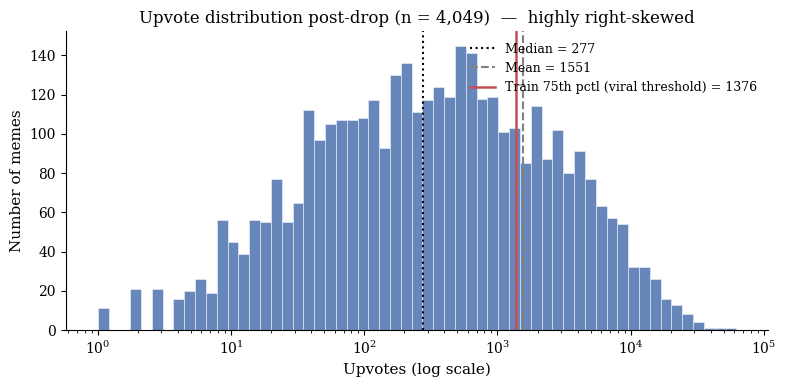

In [81]:
combined = pd.concat([train, val, test], ignore_index=True)
upvotes = combined['Upvotes'].values
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.logspace(0, np.log10(upvotes.max() + 1), 60)
ax.hist(upvotes, bins=bins, color=PALETTE[0], edgecolor='white', linewidth=0.4, alpha=0.85)
ax.set_xscale('log')
median_v = np.median(upvotes)
mean_v = np.mean(upvotes)
thr = thresholds['global_thr']
ax.axvline(median_v, color='black', linestyle=':', linewidth=1.5, label=f'Median = {median_v:.0f}')
ax.axvline(mean_v, color='gray', linestyle='--', linewidth=1.5, label=f'Mean = {mean_v:.0f}')
ax.axvline(thr, color=PALETTE[3], linestyle='-', linewidth=1.8, label=f'Train 75th pctl (viral threshold) = {thr:.0f}')
ax.set_xlabel('Upvotes (log scale)')
ax.set_ylabel('Number of memes')
ax.set_title(f'Upvote distribution post-drop (n = {len(combined):,})  —  highly right-skewed')
ax.legend(loc='upper right', frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
save_fig(fig, 'fig_upvote_distribution')
plt.show()


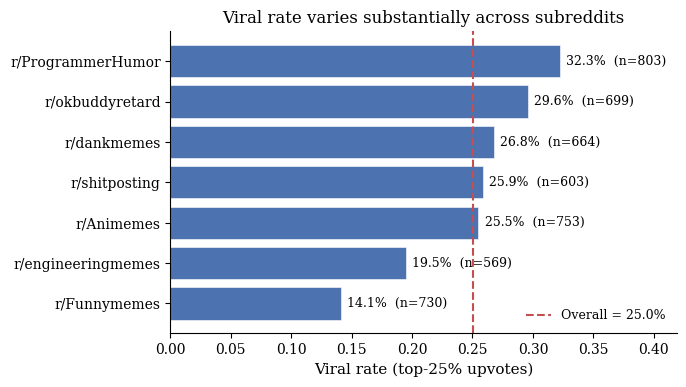

In [82]:
combined_predrop = pd.concat([train_old, val_old, test_old], ignore_index=True)
vr = combined_predrop.groupby('Category').agg(viral_rate=('is_viral', 'mean'), n=('is_viral', 'size')).sort_values('viral_rate')
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh([f'r/{s}' for s in vr.index], vr['viral_rate'], color=PALETTE[0], edgecolor='white', linewidth=0.4)
overall = combined_predrop['is_viral'].mean()
ax.axvline(overall, color=PALETTE[3], linestyle='--', linewidth=1.5, label=f'Overall = {overall:.1%}')
for bar, n_, vr_val in zip(bars, vr['n'], vr['viral_rate']):
    ax.text(vr_val + 0.005, bar.get_y() + bar.get_height() / 2, f'{vr_val:.1%}  (n={n_})', va='center', fontsize=9)
ax.set_xlabel('Viral rate (top-25% upvotes)')
ax.set_title('Viral rate varies substantially across subreddits')
ax.set_xlim(0, max(vr['viral_rate']) * 1.3)
ax.legend(loc='lower right', frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
save_fig(fig, 'fig_viral_rate_by_subreddit')
plt.show()


In [83]:
LEAKAGE_FORBIDDEN = {'Upvotes': 'IS the source of the label', 'log_upvotes': 'monotonic transform of Upvotes', 'is_viral': 'original label', 'is_viral_global': 'one of our targets', 'is_viral_local': 'one of our targets', 'Number of Comments': 'measured after posting; high if viral', 'Upvote Ratio': 'measured after voting begins'}
LIKELY_RISKY = {'Total Karma': 'scrape-time karma, not post-time karma -> partial leakage', 'Comment Karma': 'same as above', 'Author': 'possible target leakage if author appears in multiple splits', 'File Name': 'identifier; often encodes scrape order', 'Post URL': 'identifier', 'Cake Day': 'use account_age_days (post-time) instead'}
SAFE_FEATURES_BASELINE = ['Category', 'Time of Day', 'post_day', 'title_len', 'ocr_len', 'post_hour', 'account_age_days']
pass
for k, v in LEAKAGE_FORBIDDEN.items():
    pass
pass
for k, v in LIKELY_RISKY.items():
    pass
pass
for f in SAFE_FEATURES_BASELINE:
    pass


In [84]:
def _metrics(y_true, y_pred, y_proba):
    return {'accuracy': accuracy_score(y_true, y_pred), 'roc_auc': roc_auc_score(y_true, y_proba), 'auprc': average_precision_score(y_true, y_proba), 'f1_macro': f1_score(y_true, y_pred, average='macro'), 'f1_viral': f1_score(y_true, y_pred, pos_label=1), 'brier': brier_score_loss(y_true, y_proba)}

def bootstrap_ci(y_true, y_pred, y_proba, n_iter=200, seed=42):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    aucs, auprcs, f1s = ([], [], [])
    for _ in range(n_iter):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_proba[idx]))
        auprcs.append(average_precision_score(y_true[idx], y_proba[idx]))
        f1s.append(f1_score(y_true[idx], y_pred[idx], pos_label=1))

    def ci(a):
        return (np.mean(a), np.percentile(a, 2.5), np.percentile(a, 97.5))
    return {'roc_auc_ci': ci(aucs), 'auprc_ci': ci(auprcs), 'f1_viral_ci': ci(f1s)}


In [85]:
def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test, model_name='model', subreddit_test=None, plot=False, bootstrap_iter=200):
    report = {'model_name': model_name}
    for split_name, X, y in [('train', X_train, y_train), ('val', X_val, y_val), ('test', X_test, y_test)]:
        proba = model.predict_proba(X)[:, 1]
        pred = (proba >= 0.5).astype(int)
        report[split_name] = _metrics(np.asarray(y), pred, proba)
        if split_name == 'test':
            report['test_proba'] = proba
            report['test_pred'] = pred
    report['test_ci'] = bootstrap_ci(np.asarray(y_test), report['test_pred'], report['test_proba'], n_iter=bootstrap_iter)
    if subreddit_test is not None:
        per_sub = {}
        for sub in np.unique(subreddit_test):
            mask = subreddit_test == sub
            if mask.sum() > 5 and len(np.unique(np.asarray(y_test)[mask])) > 1:
                per_sub[sub] = {'n': int(mask.sum()), 'f1_viral': f1_score(np.asarray(y_test)[mask], report['test_pred'][mask], pos_label=1), 'roc_auc': roc_auc_score(np.asarray(y_test)[mask], report['test_proba'][mask])}
        report['per_subreddit'] = per_sub
    pass
    for split in ['train', 'val', 'test']:
        m = report[split]
        pass
    ci = report['test_ci']
    pass
    pass
    pass
    pass
    if 'per_subreddit' in report:
        pass
        for sub, v in sorted(report['per_subreddit'].items(), key=lambda x: -x[1]['f1_viral']):
            pass
    if plot:
        fig, axes = plt.subplots(1, 4, figsize=(18, 4))
        fpr, tpr, _ = roc_curve(y_test, report['test_proba'])
        axes[0].plot(fpr, tpr, label=f'AUC={report['test']['roc_auc']:.3f}')
        axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
        axes[0].set_title('ROC (test)')
        axes[0].legend()
        axes[0].set_xlabel('FPR')
        axes[0].set_ylabel('TPR')
        prec, rec, _ = precision_recall_curve(y_test, report['test_proba'])
        axes[1].plot(rec, prec, label=f'AUPRC={report['test']['auprc']:.3f}')
        axes[1].axhline(np.mean(y_test), color='k', linestyle='--', alpha=0.3, label=f'baseline={np.mean(y_test):.2f}')
        axes[1].set_title('Precision-Recall (test)')
        axes[1].legend()
        axes[1].set_xlabel('Recall')
        axes[1].set_ylabel('Precision')
        try:
            frac_pos, mean_pred = calibration_curve(y_test, report['test_proba'], n_bins=10, strategy='quantile')
            axes[2].plot(mean_pred, frac_pos, 'o-')
            axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.3)
            axes[2].set_title(f'Calibration (Brier={report['test']['brier']:.3f})')
            axes[2].set_xlabel('Predicted prob.')
            axes[2].set_ylabel('Empirical freq.')
        except Exception as e:
            axes[2].set_title(f'Calibration unavailable: {e}')
        cm = confusion_matrix(y_test, report['test_pred'])
        axes[3].imshow(cm, cmap='Blues')
        for i in range(2):
            for j in range(2):
                axes[3].text(j, i, cm[i, j], ha='center', va='center', fontsize=14)
        axes[3].set_xticks([0, 1])
        axes[3].set_yticks([0, 1])
        axes[3].set_xticklabels(['Not Viral', 'Viral'])
        axes[3].set_yticklabels(['Not Viral', 'Viral'])
        axes[3].set_xlabel('Predicted')
        axes[3].set_ylabel('True')
        axes[3].set_title('Confusion matrix (test)')
        plt.suptitle(f'{model_name} — diagnostics', y=1.02)
        plt.tight_layout()
        plt.show()
    return report


In [86]:
def mcnemar_test(y_true, pred_a, pred_b, model_a='A', model_b='B'):
    from scipy.stats import binomtest
    y_true = np.asarray(y_true)
    pred_a = np.asarray(pred_a)
    pred_b = np.asarray(pred_b)
    a_correct = pred_a == y_true
    b_correct = pred_b == y_true
    n_a_only = int((a_correct & ~b_correct).sum())
    n_b_only = int((~a_correct & b_correct).sum())
    n = n_a_only + n_b_only
    if n == 0:
        return {'p_value': 1.0, 'note': 'identical predictions'}
    res = binomtest(n_a_only, n, p=0.5, alternative='two-sided')
    return {f'{model_a}_correct_only': n_a_only, f'{model_b}_correct_only': n_b_only, 'p_value': res.pvalue, 'better': model_a if n_a_only > n_b_only else model_b, 'note': '%s wins on %d disagreements; p=%.4f' % (model_a if n_a_only > n_b_only else model_b, n, res.pvalue)}


## Stage 1: Metadata Baseline

In [87]:
def prepare_features(train, val, test, feature_cols, target_col, cat_cols):
    train, val, test = (train.copy(), val.copy(), test.copy())
    encoders = {}
    for c in cat_cols:
        le = LabelEncoder()
        train[c] = le.fit_transform(train[c].astype(str))
        seen = set(le.classes_)
        val[c] = val[c].astype(str).apply(lambda x: x if x in seen else le.classes_[0])
        test[c] = test[c].astype(str).apply(lambda x: x if x in seen else le.classes_[0])
        val[c] = le.transform(val[c])
        test[c] = le.transform(test[c])
        encoders[c] = le
    return (train[feature_cols].values, train[target_col].values, val[feature_cols].values, val[target_col].values, test[feature_cols].values, test[target_col].values, encoders)


In [88]:
CAT_COLS = ['Category', 'Time of Day', 'post_day']
FEATURES = SAFE_FEATURES_BASELINE
X_tr, y_tr, X_va, y_va, X_te, y_te, _ = prepare_features(train, val, test, FEATURES, 'is_viral_global', CAT_COLS)
scale_pos_weight = (y_tr == 0).sum() / max(1, (y_tr == 1).sum())
pass
baseline_g = xgb.XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6, scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42, n_jobs=-1)
baseline_g.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
report_global = evaluate_model(baseline_g, X_tr, y_tr, X_va, y_va, X_te, y_te, model_name='Stage1-Baseline-Global', subreddit_test=test['Category'].values)


In [89]:
X_tr_l, y_tr_l, X_va_l, y_va_l, X_te_l, y_te_l, _ = prepare_features(train, val, test, FEATURES, 'is_viral_local', CAT_COLS)
scale_pos_weight_l = (y_tr_l == 0).sum() / max(1, (y_tr_l == 1).sum())
baseline_l = xgb.XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6, scale_pos_weight=scale_pos_weight_l, eval_metric='logloss', random_state=42, n_jobs=-1)
baseline_l.fit(X_tr_l, y_tr_l, eval_set=[(X_va_l, y_va_l)], verbose=False)
report_local = evaluate_model(baseline_l, X_tr_l, y_tr_l, X_va_l, y_va_l, X_te_l, y_te_l, model_name='Stage1-Baseline-Local', subreddit_test=test['Category'].values)


In [90]:
stage1_summary = pd.DataFrame([
    {
        'model': r['model_name'],
        'val_AUC': r['val']['roc_auc'],
        'test_AUC': r['test']['roc_auc'],
        'test_AUPRC': r['test']['auprc'],
        'test_F1viral': r['test']['f1_viral'],
        'test_AUC_CI': f"[{r['test_ci']['roc_auc_ci'][1]:.3f}, {r['test_ci']['roc_auc_ci'][2]:.3f}]",
    }
    for r in [report_global, report_local]
]).round(4)
display(stage1_summary)


,model,val_AUC,test_AUC,test_AUPRC,test_F1viral,test_AUC_CI
0,Stage1-Baseline-Global,0.6385,0.5383,0.2508,0.3269,"[0.485, 0.594]"
1,Stage1-Baseline-Local,0.5911,0.5374,0.1575,0.2183,"[0.479, 0.601]"


## Stage 2: Engineered Metadata Features

In [91]:
def train_xgb_with_early_stopping(X_train, y_train, X_val, y_val, max_rounds=2000, patience=50, max_depth=4, learning_rate=0.05, reg_alpha=0.1, reg_lambda=1.0, subsample=0.8, colsample_bytree=0.8, seed=42, verbose=False):
    """
    Fixed hyperparameters across all Stage 2 experiments — only n_estimators
    is tuned via early stopping on val. This makes ablations directly comparable.
    """
    scale_pos_weight = (y_train == 0).sum() / max(1, (y_train == 1).sum())
    model = xgb.XGBClassifier(n_estimators=max_rounds, learning_rate=learning_rate, max_depth=max_depth, reg_alpha=reg_alpha, reg_lambda=reg_lambda, subsample=subsample, colsample_bytree=colsample_bytree, scale_pos_weight=scale_pos_weight, eval_metric='auc', early_stopping_rounds=patience, random_state=seed, n_jobs=-1)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=verbose)
    if verbose:
        pass
    return model


In [92]:
def add_cyclical_time(df):
    """
    Cyclical encoding for hour-of-day and day-of-week, plus simple flags.
    All transforms are deterministic — no per-subreddit stats needed.
    """
    df = df.copy()
    df['sin_hour'] = np.sin(2 * np.pi * df['post_hour'] / 24)
    df['cos_hour'] = np.cos(2 * np.pi * df['post_hour'] / 24)
    dow_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}
    df['dow_int'] = df['post_day'].map(dow_map)
    df['sin_dow'] = np.sin(2 * np.pi * df['dow_int'] / 7)
    df['cos_dow'] = np.cos(2 * np.pi * df['dow_int'] / 7)
    df['is_weekend'] = df['dow_int'].isin([5, 6]).astype(int)
    df['month_of_year'] = pd.to_datetime(df['Created Time']).dt.month
    return df
train_c = add_cyclical_time(train)
val_c = add_cyclical_time(val)
test_c = add_cyclical_time(test)
CYCLICAL_FEATURES = ['sin_hour', 'cos_hour', 'sin_dow', 'cos_dow', 'is_weekend', 'month_of_year']
pass
pass


In [93]:
def fit_subreddit_stats(train_df, sub_col='Category'):
    """
    Compute per-subreddit statistics on TRAINING DATA ONLY.
    Returns a dict that can be saved/loaded for inference.
    """
    stats = {}
    for col in ['title_len', 'ocr_len', 'account_age_days']:
        g = train_df.groupby(sub_col)[col]
        stats[f'{col}_mean'] = g.mean().to_dict()
        stats[f'{col}_std'] = g.std().fillna(1.0).clip(lower=1e-06).to_dict()
        stats[f'{col}_quantiles'] = train_df.groupby(sub_col)[col].apply(lambda s: np.quantile(s, np.linspace(0, 1, 101))).to_dict()
    hour_dist = train_df.groupby([sub_col, 'post_hour']).size().unstack(fill_value=0)
    stats['peak_hour'] = hour_dist.idxmax(axis=1).to_dict()
    stats['peak_hour_top3'] = {sub: set(row.nlargest(3).index) for sub, row in hour_dist.iterrows()}
    train_df = train_df.copy()
    if 'log_upvotes' not in train_df.columns:
        train_df['log_upvotes'] = np.log1p(train_df['Upvotes'])
    stats['sub_log_upvotes_median'] = train_df.groupby(sub_col)['log_upvotes'].median().to_dict()
    stats['sub_viral_rate'] = train_df.groupby(sub_col)['is_viral_global'].mean().to_dict()
    stats['_global'] = {'title_len_mean': train_df['title_len'].mean(), 'title_len_std': max(train_df['title_len'].std(), 1e-06), 'ocr_len_mean': train_df['ocr_len'].mean(), 'ocr_len_std': max(train_df['ocr_len'].std(), 1e-06), 'account_age_days_mean': train_df['account_age_days'].mean(), 'account_age_days_std': max(train_df['account_age_days'].std(), 1e-06), 'sub_log_upvotes_median': train_df['log_upvotes'].median(), 'sub_viral_rate': train_df['is_viral_global'].mean(), 'peak_hour': int(train_df['post_hour'].mode().iloc[0])}
    return stats


In [94]:
def _circular_hour_distance(h1, h2):
    """Minimum angular distance between two hours on a 24-hour clock (0-12)."""
    d = np.abs(h1 - h2) % 24
    return np.minimum(d, 24 - d)

def _percentile_rank_lookup(value, quantiles):
    """Approximate percentile rank of `value` against precomputed `quantiles` (length 101)."""
    return float(np.searchsorted(quantiles, value, side='right')) / 100.0

def add_subreddit_relative_features(df, stats, sub_col='Category'):
    """
    Apply training-fitted subreddit statistics to add relative features.
    Works on train/val/test identically.
    """
    df = df.copy()
    g = stats['_global']

    def lookup(d, sub, fallback):
        return d.get(sub, fallback)
    for col in ['title_len', 'ocr_len', 'account_age_days']:
        m_d = stats[f'{col}_mean']
        s_d = stats[f'{col}_std']
        means = df[sub_col].map(lambda s: lookup(m_d, s, g[f'{col}_mean']))
        stds = df[sub_col].map(lambda s: lookup(s_d, s, g[f'{col}_std']))
        df[f'{col}_zscore'] = (df[col] - means) / stds.clip(lower=1e-06)
    for col in ['title_len', 'ocr_len']:
        q_d = stats[f'{col}_quantiles']
        global_q = np.linspace(0, df[col].max() if len(df) else 1, 101)
        df[f'{col}_pct'] = [_percentile_rank_lookup(v, q_d.get(s, global_q)) for v, s in zip(df[col].values, df[sub_col].values)]
    peak = df[sub_col].map(lambda s: stats['peak_hour'].get(s, g['peak_hour']))
    df['hour_dist_from_sub_peak'] = _circular_hour_distance(df['post_hour'].values, peak.values)
    df['posted_in_sub_peak_window'] = df.apply(lambda r: int(r['post_hour'] in stats['peak_hour_top3'].get(r[sub_col], {g['peak_hour']})), axis=1)
    df['sub_baseline_log_upvotes'] = df[sub_col].map(lambda s: stats['sub_log_upvotes_median'].get(s, g['sub_log_upvotes_median']))
    df['sub_baseline_viral_rate'] = df[sub_col].map(lambda s: stats['sub_viral_rate'].get(s, g['sub_viral_rate']))
    return df


In [95]:
sub_stats = fit_subreddit_stats(train_c)
train_m2 = add_subreddit_relative_features(train_c, sub_stats)
val_m2 = add_subreddit_relative_features(val_c, sub_stats)
test_m2 = add_subreddit_relative_features(test_c, sub_stats)
M2_FEATURES = ['title_len_zscore', 'ocr_len_zscore', 'account_age_days_zscore', 'title_len_pct', 'ocr_len_pct', 'hour_dist_from_sub_peak', 'posted_in_sub_peak_window', 'sub_baseline_log_upvotes', 'sub_baseline_viral_rate']
pass
for sub in sorted(sub_stats['sub_log_upvotes_median'].keys()):
    pass
pass
pass
pass


In [96]:
def prepare_features(train, val, test, feature_cols, target_col, cat_cols):
    train, val, test = (train.copy(), val.copy(), test.copy())
    for c in cat_cols:
        if c not in feature_cols:
            continue
        le = LabelEncoder()
        train[c] = le.fit_transform(train[c].astype(str))
        seen = set(le.classes_)
        val[c] = val[c].astype(str).apply(lambda x: x if x in seen else le.classes_[0])
        test[c] = test[c].astype(str).apply(lambda x: x if x in seen else le.classes_[0])
        val[c] = le.transform(val[c])
        test[c] = le.transform(test[c])
    return (train[feature_cols].values, train[target_col].values, val[feature_cols].values, val[target_col].values, test[feature_cols].values, test[target_col].values)
FEATURES_A = SAFE_FEATURES_BASELINE
FEATURES_B = FEATURES_A + CYCLICAL_FEATURES
FEATURES_C = FEATURES_A + M2_FEATURES
FEATURES_D = FEATURES_A + CYCLICAL_FEATURES + M2_FEATURES
FEATURE_SETS = {'A_baseline_ES': FEATURES_A, 'B_plus_cyclical': FEATURES_B, 'C_plus_M2': FEATURES_C, 'D_full_M1_M2': FEATURES_D}
CAT_COLS = ['Category', 'Time of Day', 'post_day']
pass
for name, feats in FEATURE_SETS.items():
    pass


In [97]:
def run_config(features, target_col, name, train_df, val_df, test_df):
    X_tr, y_tr, X_va, y_va, X_te, y_te = prepare_features(train_df, val_df, test_df, features, target_col, CAT_COLS)
    model = train_xgb_with_early_stopping(X_tr, y_tr, X_va, y_va, verbose=False)
    report = evaluate_model(model, X_tr, y_tr, X_va, y_va, X_te, y_te, model_name=name, subreddit_test=test_df['Category'].values, plot=False)
    report['model_obj'] = model
    report['features'] = features
    report['best_iter'] = model.best_iteration
    return report


In [98]:
all_reports = {'global': {}, 'local': {}}
for target in ['is_viral_global', 'is_viral_local']:
    pass
    for name, features in FEATURE_SETS.items():
        full_name = f'{name}_{target.replace('is_viral_', '')}'
        all_reports[target.replace('is_viral_', '')][name] = run_config(features, target, full_name, train_m2, val_m2, test_m2)


In [99]:
def make_summary(reports_dict, target_name):
    rows = []
    for name, r in reports_dict.items():
        rows.append({
            'config': name,
            '#feat': len(r['features']),
            'best_iter': r['best_iter'],
            'val_AUC': r['val']['roc_auc'],
            'test_AUC': r['test']['roc_auc'],
            'test_AUPRC': r['test']['auprc'],
            'test_F1viral': r['test']['f1_viral'],
            'test_AUC_CI': f"[{r['test_ci']['roc_auc_ci'][1]:.3f}, {r['test_ci']['roc_auc_ci'][2]:.3f}]",
        })
    return pd.DataFrame(rows).round(4)

summary_m2_global = make_summary(all_reports['global'], 'global')
summary_m2_local = make_summary(all_reports['local'], 'local')
display(summary_m2_global)
display(summary_m2_local)


,config,#feat,best_iter,val_AUC,test_AUC,test_AUPRC,test_F1viral,test_AUC_CI
0,A_baseline_ES,7,49,0.6967,0.6162,0.3564,0.3611,"[0.570, 0.675]"
1,B_plus_cyclical,13,10,0.6984,0.5667,0.2824,0.3494,"[0.517, 0.623]"
2,C_plus_M2,16,20,0.7292,0.6889,0.4197,0.4342,"[0.643, 0.741]"
3,D_full_M1_M2,22,34,0.7145,0.5994,0.2941,0.3720,"[0.544, 0.650]"


,config,#feat,best_iter,val_AUC,test_AUC,test_AUPRC,test_F1viral,test_AUC_CI
0,A_baseline_ES,7,29,0.6354,0.5539,0.1919,0.2543,"[0.490, 0.618]"
1,B_plus_cyclical,13,62,0.6325,0.5673,0.2067,0.2746,"[0.503, 0.631]"
2,C_plus_M2,16,76,0.7036,0.6751,0.2622,0.3228,"[0.621, 0.737]"
3,D_full_M1_M2,22,68,0.7085,0.6559,0.2620,0.3130,"[0.599, 0.711]"


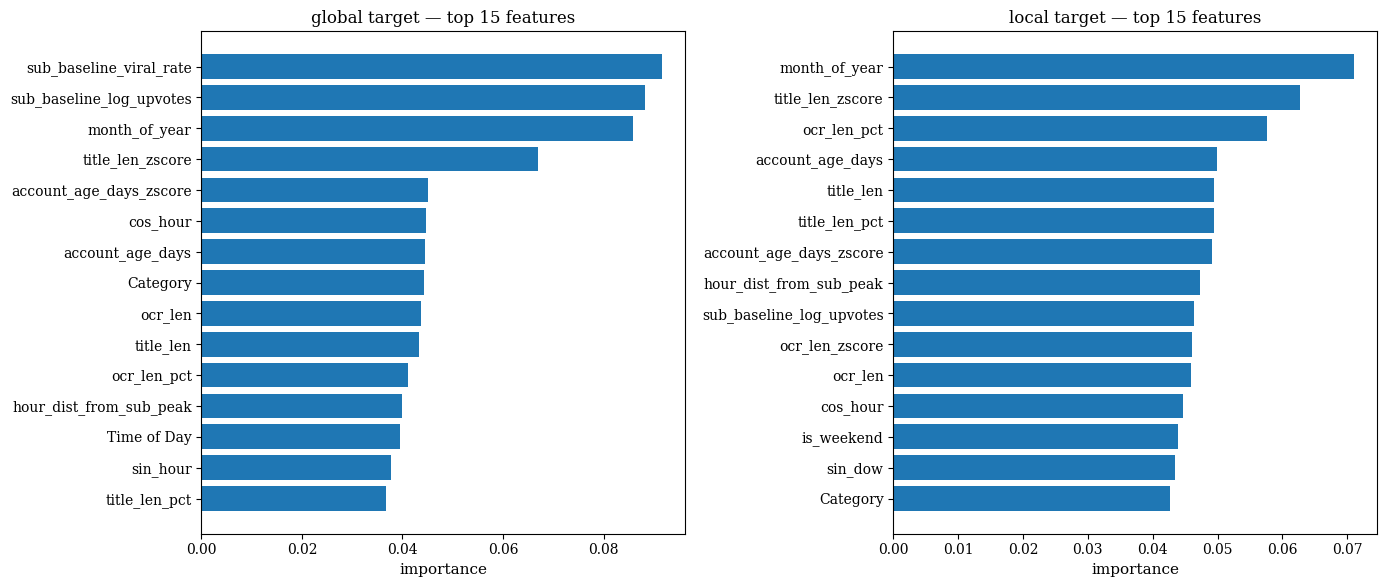

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)
for ax, target in zip(axes, ['global', 'local']):
    r = all_reports[target]['D_full_M1_M2']
    feat_imp = pd.DataFrame({'feature': r['features'], 'importance': r['model_obj'].feature_importances_}).sort_values('importance', ascending=True).tail(15)
    ax.barh(feat_imp['feature'], feat_imp['importance'])
    ax.set_title(f'{target} target — top 15 features')
    ax.set_xlabel('importance')
plt.tight_layout()
plt.show()


## Stage 2: Text And Image Embeddings

In [101]:
SBERT_MODEL = 'sentence-transformers/all-mpnet-base-v2'
SBERT_DIM = 768
CACHE_DIR = f'{OUT_DIR}/embeddings'
os.makedirs(CACHE_DIR, exist_ok=True)

SBERT_DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available() else 'cpu')
SBERT_BATCH_SIZE = 128 if SBERT_DEVICE == 'cuda' else 32

def encode_sbert(texts, model, batch_size=SBERT_BATCH_SIZE):
    texts = [t if isinstance(t, str) and len(t.strip()) > 0 else '[empty]' for t in texts]
    return model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False,
    )

def maybe_compute_or_load(cache_path, compute_fn):
    if os.path.exists(cache_path):
        return np.load(cache_path)
    arr = compute_fn()
    np.save(cache_path, arr)
    return arr


In [102]:
USE_MOCK_SBERT = False
sbert_model = None
try:
    from sentence_transformers import SentenceTransformer
    sbert_model = SentenceTransformer(SBERT_MODEL, device=SBERT_DEVICE)
    SBERT_DIM = sbert_model.get_sentence_embedding_dimension()
except Exception:
    USE_MOCK_SBERT = True

def get_sbert_embeddings(texts, cache_name):
    cache_path = f'{CACHE_DIR}/{cache_name}.npy'

    def compute():
        if USE_MOCK_SBERT:
            return np.random.RandomState(hash(cache_name) % 2 ** 32).randn(len(texts), SBERT_DIM).astype(np.float32)
        return encode_sbert(texts, sbert_model).astype(np.float32)

    return maybe_compute_or_load(cache_path, compute)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5553.04it/s]


In [103]:
title_train = get_sbert_embeddings(train['Title'].tolist(), 'sbert_title_train')


In [104]:
title_val = get_sbert_embeddings(val['Title'].tolist(), 'sbert_title_val')


In [105]:
title_test = get_sbert_embeddings(test['Title'].tolist(), 'sbert_title_test')


In [106]:
ocr_train = get_sbert_embeddings(train['Extracted Text'].fillna('').tolist(), 'sbert_ocr_train')


In [107]:
ocr_val = get_sbert_embeddings(val['Extracted Text'].fillna('').tolist(), 'sbert_ocr_val')


In [108]:
ocr_test = get_sbert_embeddings(test['Extracted Text'].fillna('').tolist(), 'sbert_ocr_test')


In [109]:
def cosine_similarity_paired(a, b, eps=1e-08):
    a_norm = a / (np.linalg.norm(a, axis=1, keepdims=True) + eps)
    b_norm = b / (np.linalg.norm(b, axis=1, keepdims=True) + eps)
    return (a_norm * b_norm).sum(axis=1)
train_m2['title_ocr_cosine_sim'] = cosine_similarity_paired(title_train, ocr_train)
val_m2['title_ocr_cosine_sim'] = cosine_similarity_paired(title_val, ocr_val)
test_m2['title_ocr_cosine_sim'] = cosine_similarity_paired(title_test, ocr_test)
pass
pass
pass


In [110]:
USE_MOCK_CLIP = False
CLIP_DIM = 512
ORIG_DATA_DIR = DATA_DIR

def load_clip_images():
    """Load the three original CLIP .npy files and build a File Name -> embedding lookup."""
    paths_npy = [f'{ORIG_DATA_DIR}/clip_image_train.npy', f'{ORIG_DATA_DIR}/clip_image_val.npy', f'{ORIG_DATA_DIR}/clip_image_test.npy']
    paths_csv = [f'{ORIG_DATA_DIR}/train.csv', f'{ORIG_DATA_DIR}/val.csv', f'{ORIG_DATA_DIR}/test.csv']
    if not all((os.path.exists(p) for p in paths_npy + paths_csv)):
        raise FileNotFoundError('Original CLIP .npy or CSV files missing')
    lookup = {}
    for npy, csv in zip(paths_npy, paths_csv):
        emb = np.load(npy)
        df = pd.read_csv(csv)
        assert len(emb) == len(df), f'mismatched lengths: {npy}'
        for fn, vec in zip(df['File Name'].values, emb):
            lookup[fn] = vec
    return lookup
try:
    clip_lookup = load_clip_images()
    pass
except Exception as e:
    pass
    pass
    USE_MOCK_CLIP = True
    rng = np.random.RandomState(123)
    all_filenames = pd.concat([train['File Name'], val['File Name'], test['File Name']]).unique()
    clip_lookup = {fn: rng.randn(CLIP_DIM).astype(np.float32) for fn in all_filenames}


In [111]:
def lookup_clip_image(df, lookup, dim=512):
    miss = 0
    out = np.zeros((len(df), dim), dtype=np.float32)
    for i, fn in enumerate(df['File Name'].values):
        if fn in lookup:
            out[i] = lookup[fn]
        else:
            miss += 1
    if miss > 0:
        pass
    return out
clip_train = lookup_clip_image(train_m2, clip_lookup, dim=CLIP_DIM)
clip_val = lookup_clip_image(val_m2, clip_lookup, dim=CLIP_DIM)
clip_test = lookup_clip_image(test_m2, clip_lookup, dim=CLIP_DIM)
pass


In [112]:
if 'clip_train' not in globals():
    USE_MOCK_CLIP = False
    CLIP_DIM = 512
    ORIG_DATA_DIR = DATA_DIR

    def load_clip_images():
        paths_npy = [f'{ORIG_DATA_DIR}/clip_image_train.npy', f'{ORIG_DATA_DIR}/clip_image_val.npy', f'{ORIG_DATA_DIR}/clip_image_test.npy']
        paths_csv = [f'{ORIG_DATA_DIR}/train.csv', f'{ORIG_DATA_DIR}/val.csv', f'{ORIG_DATA_DIR}/test.csv']
        if not all(os.path.exists(p) for p in paths_npy + paths_csv):
            raise FileNotFoundError('Original CLIP .npy or CSV files missing')
        lookup = {}
        for npy, csv in zip(paths_npy, paths_csv):
            emb = np.load(npy)
            df = pd.read_csv(csv)
            assert len(emb) == len(df), f'mismatched lengths: {npy}'
            for fn, vec in zip(df['File Name'].values, emb):
                lookup[fn] = vec
        return lookup

    def lookup_clip_image(df, lookup, dim=512):
        out = np.zeros((len(df), dim), dtype=np.float32)
        for i, fn in enumerate(df['File Name'].values):
            if fn in lookup:
                out[i] = lookup[fn]
        return out

    try:
        clip_lookup = load_clip_images()
    except Exception:
        USE_MOCK_CLIP = True
        rng = np.random.RandomState(123)
        all_filenames = pd.concat([train['File Name'], val['File Name'], test['File Name']]).unique()
        clip_lookup = {fn: rng.randn(CLIP_DIM).astype(np.float32) for fn in all_filenames}

    clip_train = lookup_clip_image(train_m2, clip_lookup, dim=CLIP_DIM)
    clip_val = lookup_clip_image(val_m2, clip_lookup, dim=CLIP_DIM)
    clip_test = lookup_clip_image(test_m2, clip_lookup, dim=CLIP_DIM)

PCA_DIMS = 32

def fit_apply_pca(train_emb, val_emb, test_emb, n_components, name):
    pca = PCA(n_components=n_components, random_state=42)
    pca.fit(train_emb)
    var_explained = pca.explained_variance_ratio_.sum()
    pass
    return (pca.transform(train_emb).astype(np.float32), pca.transform(val_emb).astype(np.float32), pca.transform(test_emb).astype(np.float32), pca)
pass
title_train_p, title_val_p, title_test_p, pca_title = fit_apply_pca(title_train, title_val, title_test, PCA_DIMS, 'sBERT-title')
ocr_train_p, ocr_val_p, ocr_test_p, pca_ocr = fit_apply_pca(ocr_train, ocr_val, ocr_test, PCA_DIMS, 'sBERT-ocr')
clip_train_p, clip_val_p, clip_test_p, pca_clip = fit_apply_pca(clip_train, clip_val, clip_test, PCA_DIMS, 'CLIP-image')


In [113]:
TABULAR_FEATURES = ['Category', 'Time of Day', 'post_day', 'title_len', 'ocr_len', 'post_hour', 'account_age_days', 'sin_hour', 'cos_hour', 'sin_dow', 'cos_dow', 'is_weekend', 'month_of_year', 'title_len_zscore', 'ocr_len_zscore', 'account_age_days_zscore', 'title_len_pct', 'ocr_len_pct', 'hour_dist_from_sub_peak', 'posted_in_sub_peak_window', 'sub_baseline_log_upvotes', 'sub_baseline_viral_rate', 'title_ocr_cosine_sim']
pass


In [114]:
def build_X(df, tabular_cols, embedding_blocks=()):
    parts = [df[tabular_cols].values.astype(np.float32)]
    for emb in embedding_blocks:
        parts.append(np.asarray(emb, dtype=np.float32))
    return np.concatenate(parts, axis=1)

def encode_categoricals(train, val, test, cat_cols):
    train, val, test = (train.copy(), val.copy(), test.copy())
    for c in cat_cols:
        le = LabelEncoder()
        train[c] = le.fit_transform(train[c].astype(str))
        seen = set(le.classes_)
        val[c] = val[c].astype(str).apply(lambda x: x if x in seen else le.classes_[0])
        test[c] = test[c].astype(str).apply(lambda x: x if x in seen else le.classes_[0])
        val[c] = le.transform(val[c])
        test[c] = le.transform(test[c])
    return (train, val, test)
CAT_COLS = ['Category', 'Time of Day', 'post_day']
train_e, val_e, test_e = encode_categoricals(train_m2, val_m2, test_m2, CAT_COLS)


## Multimodal Ablation

In [115]:
def train_xgb(X_train, y_train, X_val, y_val, max_rounds=2000, patience=50, max_depth=4, learning_rate=0.05, reg_alpha=0.1, reg_lambda=1.0, subsample=0.8, colsample_bytree=0.8):
    spw = (y_train == 0).sum() / max(1, (y_train == 1).sum())
    m = xgb.XGBClassifier(n_estimators=max_rounds, learning_rate=learning_rate, max_depth=max_depth, reg_alpha=reg_alpha, reg_lambda=reg_lambda, subsample=subsample, colsample_bytree=colsample_bytree, scale_pos_weight=spw, eval_metric='auc', early_stopping_rounds=patience, random_state=42, n_jobs=-1)
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return m

def get_configs():
    return {'D_baseline_M1M2': ((), '0'), 'E_plus_sbert_title': ((title_train_p, title_val_p, title_test_p), f'{PCA_DIMS}'), 'F_plus_sbert_full': ((title_train_p, ocr_train_p, title_val_p, ocr_val_p, title_test_p, ocr_test_p), f'2x{PCA_DIMS}'), 'G_plus_clip_image': ((clip_train_p, clip_val_p, clip_test_p), f'{PCA_DIMS}'), 'H_full_multimodal': ((title_train_p, ocr_train_p, clip_train_p, title_val_p, ocr_val_p, clip_val_p, title_test_p, ocr_test_p, clip_test_p), f'2x{PCA_DIMS}+CLIP{PCA_DIMS}')}

def run_config(target_col, name, blocks_meta):
    """blocks_meta = tuple of three groups: train_blocks, val_blocks, test_blocks
    flattened.  We unflatten by length / 3."""
    n_blocks = len(blocks_meta) // 3
    train_blocks = blocks_meta[:n_blocks]
    val_blocks = blocks_meta[n_blocks:2 * n_blocks]
    test_blocks = blocks_meta[2 * n_blocks:]
    X_tr = build_X(train_e, TABULAR_FEATURES, train_blocks)
    X_va = build_X(val_e, TABULAR_FEATURES, val_blocks)
    X_te = build_X(test_e, TABULAR_FEATURES, test_blocks)
    y_tr = train_e[target_col].values
    y_va = val_e[target_col].values
    y_te = test_e[target_col].values
    pass
    model = train_xgb(X_tr, y_tr, X_va, y_va)
    report = evaluate_model(model, X_tr, y_tr, X_va, y_va, X_te, y_te, model_name=f'{name}_{target_col}', subreddit_test=test['Category'].values)
    report['n_features'] = X_tr.shape[1]
    return report
all_reports = {'global': {}, 'local': {}}
for target_short, target_col in [('global', 'is_viral_global'), ('local', 'is_viral_local')]:
    pass
    configs = get_configs()
    for name, (blocks, dim_summary) in configs.items():
        pass
        all_reports[target_short][name] = run_config(target_col, name, blocks)


In [116]:
def make_summary(reports_dict, target_name):
    rows = []
    for name, r in reports_dict.items():
        rows.append({
            'config': name,
            '#feat': r['n_features'],
            'val_AUC': r['val']['roc_auc'],
            'test_AUC': r['test']['roc_auc'],
            'test_AUPRC': r['test']['auprc'],
            'test_F1viral': r['test']['f1_viral'],
            'test_AUC_CI': f"[{r['test_ci']['roc_auc_ci'][1]:.3f}, {r['test_ci']['roc_auc_ci'][2]:.3f}]",
        })
    return pd.DataFrame(rows).round(4)

summary_multimodal_global = make_summary(all_reports['global'], 'global')
summary_multimodal_local = make_summary(all_reports['local'], 'local')
display(summary_multimodal_global)
display(summary_multimodal_local)


,config,#feat,val_AUC,test_AUC,test_AUPRC,test_F1viral,test_AUC_CI
0,D_baseline_M1M2,23,0.7234,0.6194,0.3038,0.3636,"[0.568, 0.665]"
1,E_plus_sbert_title,55,0.6867,0.6105,0.3031,0.3832,"[0.557, 0.658]"
2,F_plus_sbert_full,87,0.6796,0.6138,0.2956,0.3608,"[0.557, 0.664]"
3,G_plus_clip_image,55,0.7406,0.6820,0.3510,0.4383,"[0.634, 0.727]"
4,H_full_multimodal,119,0.7112,0.6729,0.3591,0.3502,"[0.619, 0.717]"


,config,#feat,val_AUC,test_AUC,test_AUPRC,test_F1viral,test_AUC_CI
0,D_baseline_M1M2,23,0.6921,0.6618,0.2983,0.3210,"[0.601, 0.731]"
1,E_plus_sbert_title,55,0.6741,0.6722,0.2476,0.2788,"[0.612, 0.724]"
2,F_plus_sbert_full,87,0.6631,0.6557,0.2747,0.2957,"[0.596, 0.715]"
3,G_plus_clip_image,55,0.6871,0.6724,0.2643,0.3377,"[0.619, 0.728]"
4,H_full_multimodal,119,0.6922,0.6863,0.2583,0.2857,"[0.628, 0.737]"


In [117]:
def importance_by_modality(report, n_tabular):
    """Sum feature importance grouped by modality block."""
    fi = report.get('model_obj', None)
    return None

def show_grouped_importance(target):
    """Re-run config H to grab feature importance and group by source."""
    target_col = 'is_viral_global' if target == 'global' else 'is_viral_local'
    blocks = (title_train_p, ocr_train_p, clip_train_p, title_val_p, ocr_val_p, clip_val_p, title_test_p, ocr_test_p, clip_test_p)
    X_tr = build_X(train_e, TABULAR_FEATURES, (title_train_p, ocr_train_p, clip_train_p))
    X_va = build_X(val_e, TABULAR_FEATURES, (title_val_p, ocr_val_p, clip_val_p))
    y_tr = train_e[target_col].values
    y_va = val_e[target_col].values
    model = train_xgb(X_tr, y_tr, X_va, y_va)
    imp = model.feature_importances_
    n_tab = len(TABULAR_FEATURES)
    n_t = title_train_p.shape[1]
    n_o = ocr_train_p.shape[1]
    n_c = clip_train_p.shape[1]
    groups = {'M1 baseline (raw)': imp[:7].sum(), 'M1+ cyclical': imp[7:13].sum(), 'M2 subreddit-relative': imp[13:22].sum(), 'title_ocr_cosine_sim': imp[22], 'sBERT title (PCA32)': imp[n_tab:n_tab + n_t].sum(), 'sBERT ocr (PCA32)': imp[n_tab + n_t:n_tab + n_t + n_o].sum(), 'CLIP image (PCA32)': imp[n_tab + n_t + n_o:].sum()}
    pass
    total = sum(groups.values())
    for k, v in sorted(groups.items(), key=lambda x: -x[1]):
        pass
    return groups
g_global = show_grouped_importance('global')
g_local = show_grouped_importance('local')


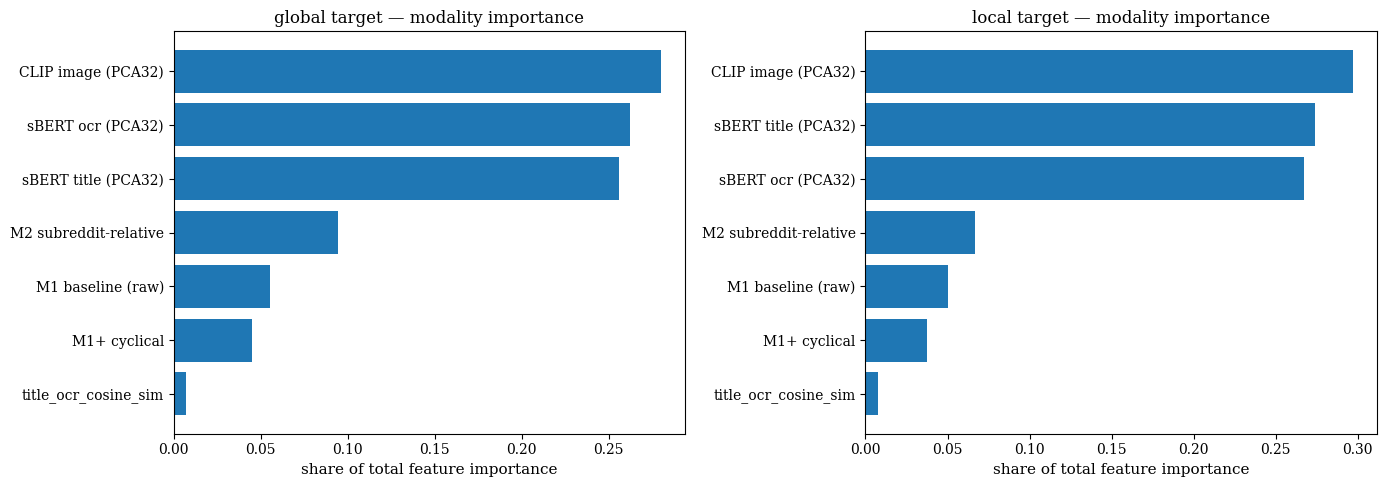

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (target, groups) in zip(axes, [('global', g_global), ('local', g_local)]):
    items = sorted(groups.items(), key=lambda x: x[1])
    labels = [k for k, _ in items]
    vals = [v / sum(groups.values()) for _, v in items]
    ax.barh(labels, vals)
    ax.set_xlabel('share of total feature importance')
    ax.set_title(f'{target} target — modality importance')
plt.tight_layout()
plt.show()


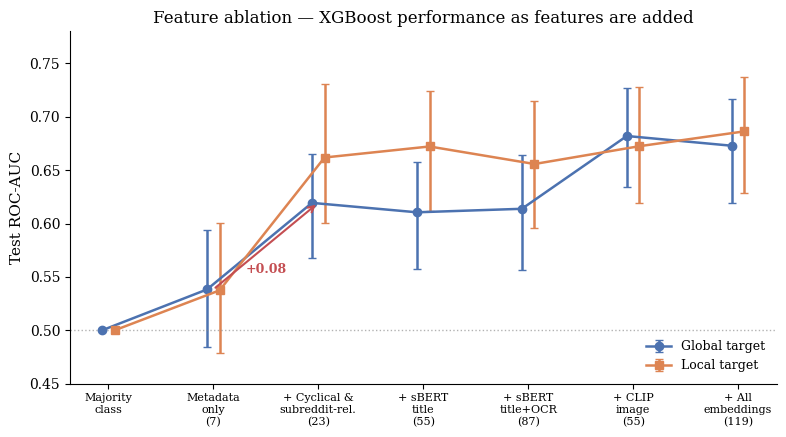

In [119]:
ablation_rows = [('Majority\nclass', None, None), ('Metadata\nonly\n(7)', report_global, report_local), ('+ Cyclical &\nsubreddit-rel.\n(23)', all_reports['global']['D_baseline_M1M2'], all_reports['local']['D_baseline_M1M2']), ('+ sBERT\ntitle\n(55)', all_reports['global']['E_plus_sbert_title'], all_reports['local']['E_plus_sbert_title']), ('+ sBERT\ntitle+OCR\n(87)', all_reports['global']['F_plus_sbert_full'], all_reports['local']['F_plus_sbert_full']), ('+ CLIP\nimage\n(55)', all_reports['global']['G_plus_clip_image'], all_reports['local']['G_plus_clip_image']), ('+ All\nembeddings\n(119)', all_reports['global']['H_full_multimodal'], all_reports['local']['H_full_multimodal'])]

def _extract(rep):
    if rep is None:
        return (0.5, 0.5, 0.5)
    auc = rep['test']['roc_auc']
    _, ci_lo, ci_hi = rep['test_ci']['roc_auc_ci']
    return (auc, ci_lo, ci_hi)
labels = [r[0] for r in ablation_rows]
g_auc, g_lo, g_hi = zip(*[_extract(r[1]) for r in ablation_rows])
l_auc, l_lo, l_hi = zip(*[_extract(r[2]) for r in ablation_rows])
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(labels))
g_err = np.array([np.array(g_auc) - np.array(g_lo), np.array(g_hi) - np.array(g_auc)])
l_err = np.array([np.array(l_auc) - np.array(l_lo), np.array(l_hi) - np.array(l_auc)])
ax.errorbar(x - 0.06, g_auc, yerr=g_err, marker='o', markersize=6, color=PALETTE[0], linewidth=1.8, capsize=3, label='Global target')
ax.errorbar(x + 0.06, l_auc, yerr=l_err, marker='s', markersize=6, color=PALETTE[1], linewidth=1.8, capsize=3, label='Local target')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.6)
diffs = np.diff(g_auc)
i_max = int(np.argmax(diffs))
ax.annotate('', xy=(i_max + 1, g_auc[i_max + 1]), xytext=(i_max, g_auc[i_max]), arrowprops=dict(arrowstyle='->', color=PALETTE[3], lw=1.5))
ax.text(i_max + 0.5, (g_auc[i_max] + g_auc[i_max + 1]) / 2 - 0.025, f'+{diffs[i_max]:.2f}', color=PALETTE[3], ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Test ROC-AUC')
ax.set_title('Feature ablation — XGBoost performance as features are added')
ax.legend(loc='lower right', frameon=False)
ax.set_ylim(0.45, 0.78)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
save_fig(fig, 'fig_feature_ablation')
plt.show()


## Stage 3: Model Zoo And Ensemble

In [120]:
X_train_full = build_X(train_e, TABULAR_FEATURES, (title_train_p, ocr_train_p, clip_train_p))
X_val_full = build_X(val_e, TABULAR_FEATURES, (title_val_p, ocr_val_p, clip_val_p))
X_test_full = build_X(test_e, TABULAR_FEATURES, (title_test_p, ocr_test_p, clip_test_p))
X_train_meta = build_X(train_e, TABULAR_FEATURES, ())
X_val_meta = build_X(val_e, TABULAR_FEATURES, ())
X_test_meta = build_X(test_e, TABULAR_FEATURES, ())
y_train_g = train_e['is_viral_global'].values
y_val_g = val_e['is_viral_global'].values
y_test_g = test_e['is_viral_global'].values
y_train_l = train_e['is_viral_local'].values
y_val_l = val_e['is_viral_local'].values
y_test_l = test_e['is_viral_local'].values
sb_title_train = title_train
sb_title_val = title_val
sb_title_test = title_test
sb_ocr_train = ocr_train
sb_ocr_val = ocr_val
sb_ocr_test = ocr_test
pass
pass


In [121]:
def report_model(name, proba_tr, proba_va, proba_te, y_tr, y_va, y_te, subreddit_test=None, t_train=None):
    pred_te = (proba_te >= 0.5).astype(int)
    rep = {'model': name, 'train': _metrics(y_tr, (proba_tr >= 0.5).astype(int), proba_tr), 'val': _metrics(y_va, (proba_va >= 0.5).astype(int), proba_va), 'test': _metrics(y_te, pred_te, proba_te), 'test_proba': proba_te, 'test_pred': pred_te, 'train_seconds': t_train}
    rep['test_ci'] = bootstrap_ci(y_te, pred_te, proba_te)
    if subreddit_test is not None:
        ps = {}
        for sub in np.unique(subreddit_test):
            mask = subreddit_test == sub
            if mask.sum() > 5 and len(np.unique(y_te[mask])) > 1:
                ps[sub] = {'n': int(mask.sum()), 'f1_viral': f1_score(y_te[mask], pred_te[mask], pos_label=1), 'roc_auc': roc_auc_score(y_te[mask], proba_te[mask])}
        rep['per_sub'] = ps
    pass
    return rep


In [122]:
def fit_logistic(X_tr, y_tr, X_va, y_va, X_te):
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)
    X_te_s = scaler.transform(X_te)
    model = LogisticRegression(penalty='l2', C=0.5, max_iter=2000, class_weight='balanced', solver='lbfgs', random_state=42)
    model.fit(X_tr_s, y_tr)
    pt = model.predict_proba(X_tr_s)[:, 1]
    pv = model.predict_proba(X_va_s)[:, 1]
    pe = model.predict_proba(X_te_s)[:, 1]
    return (pt, pv, pe, (model, scaler))


In [123]:
def fit_xgboost(X_tr, y_tr, X_va, y_va, X_te):
    spw = (y_tr == 0).sum() / max(1, (y_tr == 1).sum())
    m = xgb.XGBClassifier(n_estimators=2000, learning_rate=0.05, max_depth=4, reg_alpha=0.1, reg_lambda=1.0, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw, eval_metric='auc', early_stopping_rounds=50, random_state=42, n_jobs=-1)
    m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    return (m.predict_proba(X_tr)[:, 1], m.predict_proba(X_va)[:, 1], m.predict_proba(X_te)[:, 1], m)

def fit_lightgbm(X_tr, y_tr, X_va, y_va, X_te):
    spw = (y_tr == 0).sum() / max(1, (y_tr == 1).sum())
    m = lgb.LGBMClassifier(n_estimators=2000, learning_rate=0.05, max_depth=4, num_leaves=15, reg_alpha=0.1, reg_lambda=1.0, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw, random_state=42, n_jobs=-1, verbosity=-1)
    m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(50, verbose=False)])
    return (m.predict_proba(X_tr)[:, 1], m.predict_proba(X_va)[:, 1], m.predict_proba(X_te)[:, 1], m)

def fit_catboost(X_tr, y_tr, X_va, y_va, X_te):
    spw = (y_tr == 0).sum() / max(1, (y_tr == 1).sum())
    m = CatBoostClassifier(iterations=2000, learning_rate=0.05, depth=4, l2_leaf_reg=3.0, random_seed=42, scale_pos_weight=spw, verbose=False, early_stopping_rounds=50, eval_metric='AUC')
    m.fit(X_tr, y_tr, eval_set=(X_va, y_va), verbose=False)
    return (m.predict_proba(X_tr)[:, 1], m.predict_proba(X_va)[:, 1], m.predict_proba(X_te)[:, 1], m)


In [124]:
class MLP(nn.Module):

    def __init__(self, in_dim, hidden=128, n_layers=3, dropout=0.3):
        super().__init__()
        layers = []
        prev = in_dim
        for _ in range(n_layers):
            layers += [nn.Linear(prev, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(dropout)]
            prev = hidden
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

def _train_torch_classifier(model, X_tr, y_tr, X_va, y_va, max_epochs=200, batch_size=128, lr=0.001, weight_decay=0.0001, patience=20, verbose=False):
    """Generic PyTorch training loop with class-weighted BCE + early stopping on val AUC."""
    model = model.to(DEVICE)
    pos_w = torch.tensor([(y_tr == 0).sum() / max(1, (y_tr == 1).sum())], dtype=torch.float32, device=DEVICE)
    crit = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    Xt = torch.tensor(X_tr, dtype=torch.float32, device=DEVICE)
    yt = torch.tensor(y_tr, dtype=torch.float32, device=DEVICE)
    Xv = torch.tensor(X_va, dtype=torch.float32, device=DEVICE)
    yv = y_va
    train_loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True)
    best_auc, best_state, no_improve = (0.0, None, 0)
    for ep in range(max_epochs):
        model.train()
        for xb, yb in train_loader:
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            v_logits = model(Xv).cpu().numpy()
        v_proba = 1 / (1 + np.exp(-v_logits))
        auc = roc_auc_score(yv, v_proba)
        if auc > best_auc:
            best_auc, no_improve = (auc, 0)
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                break
        if verbose and ep % 5 == 0:
            pass
    model.load_state_dict(best_state)
    return (model, best_auc)

def _proba_torch(model, X):
    model.eval()
    Xt = torch.tensor(X, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        logits = model(Xt).cpu().numpy()
    return 1 / (1 + np.exp(-logits))

def fit_mlp(X_tr, y_tr, X_va, y_va, X_te):
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr).astype(np.float32)
    X_va_s = scaler.transform(X_va).astype(np.float32)
    X_te_s = scaler.transform(X_te).astype(np.float32)
    model = MLP(in_dim=X_tr_s.shape[1], hidden=128, n_layers=3, dropout=0.3)
    model, _ = _train_torch_classifier(model, X_tr_s, y_tr, X_va_s, y_va)
    return (_proba_torch(model, X_tr_s), _proba_torch(model, X_va_s), _proba_torch(model, X_te_s), (model, scaler))


In [125]:
class MultimodalLateFusion(nn.Module):

    def __init__(self, meta_dim, text_dim=768, image_dim=512, tower_hidden=64, tower_out=32, dropout=0.3):
        super().__init__()

        def tower(in_d):
            return nn.Sequential(nn.Linear(in_d, tower_hidden), nn.ReLU(), nn.Dropout(dropout), nn.Linear(tower_hidden, tower_out))
        self.tower_meta = tower(meta_dim)
        self.tower_title = tower(text_dim)
        self.tower_ocr = tower(text_dim)
        self.tower_image = tower(image_dim)
        self.gate = nn.Sequential(nn.Linear(tower_out * 4, 4))
        self.classifier = nn.Sequential(nn.Linear(tower_out * 4, tower_hidden), nn.ReLU(), nn.Dropout(dropout), nn.Linear(tower_hidden, 1))

    def forward(self, meta, title, ocr, image):
        m = self.tower_meta(meta)
        t = self.tower_title(title)
        o = self.tower_ocr(ocr)
        i = self.tower_image(image)
        cat = torch.cat([m, t, o, i], dim=-1)
        gates = F.softmax(self.gate(cat), dim=-1)
        weighted = torch.cat([m * gates[:, 0:1], t * gates[:, 1:2], o * gates[:, 2:3], i * gates[:, 3:4]], dim=-1)
        return (self.classifier(weighted).squeeze(-1), gates)

    def predict_proba(self, meta, title, ocr, image):
        self.eval()
        with torch.no_grad():
            logits, _ = self.forward(meta, title, ocr, image)
        return torch.sigmoid(logits).cpu().numpy()


In [126]:
def _train_late_fusion(model, meta_tr, title_tr, ocr_tr, img_tr, y_tr, meta_va, title_va, ocr_va, img_va, y_va, max_epochs=200, batch_size=64, lr=0.001, weight_decay=0.0001, patience=20):
    model = model.to(DEVICE)
    pos_w = torch.tensor([(y_tr == 0).sum() / max(1, (y_tr == 1).sum())], dtype=torch.float32, device=DEVICE)
    crit = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    def to_tensor(*arrays):
        return [torch.tensor(a, dtype=torch.float32, device=DEVICE) for a in arrays]
    m_tr, t_tr, o_tr, i_tr, ytr = to_tensor(meta_tr, title_tr, ocr_tr, img_tr, y_tr)
    m_va, t_va, o_va, i_va = to_tensor(meta_va, title_va, ocr_va, img_va)
    train_ds = TensorDataset(m_tr, t_tr, o_tr, i_tr, ytr)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    best_auc, best_state, no_improve = (0.0, None, 0)
    for ep in range(max_epochs):
        model.train()
        for batch in train_loader:
            mb, tb, ob, ib, yb = batch
            opt.zero_grad()
            logits, _ = model(mb, tb, ob, ib)
            loss = crit(logits, yb)
            loss.backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            v_logits, _ = model(m_va, t_va, o_va, i_va)
        v_proba = torch.sigmoid(v_logits).cpu().numpy()
        auc = roc_auc_score(y_va, v_proba)
        if auc > best_auc:
            best_auc, no_improve = (auc, 0)
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                break
    model.load_state_dict(best_state)
    return (model, best_auc)

def fit_late_fusion(meta_tr, title_tr, ocr_tr, img_tr, y_tr, meta_va, title_va, ocr_va, img_va, y_va, meta_te, title_te, ocr_te, img_te):
    sc_m = StandardScaler().fit(meta_tr)
    meta_tr_s = sc_m.transform(meta_tr).astype(np.float32)
    meta_va_s = sc_m.transform(meta_va).astype(np.float32)
    meta_te_s = sc_m.transform(meta_te).astype(np.float32)
    title_tr_a = title_tr.astype(np.float32)
    title_va_a = title_va.astype(np.float32)
    title_te_a = title_te.astype(np.float32)
    ocr_tr_a = ocr_tr.astype(np.float32)
    ocr_va_a = ocr_va.astype(np.float32)
    ocr_te_a = ocr_te.astype(np.float32)
    img_tr_a = img_tr.astype(np.float32)
    img_va_a = img_va.astype(np.float32)
    img_te_a = img_te.astype(np.float32)
    model = MultimodalLateFusion(meta_dim=meta_tr_s.shape[1], text_dim=title_tr_a.shape[1], image_dim=img_tr_a.shape[1], tower_hidden=64, tower_out=32, dropout=0.3)
    model, _ = _train_late_fusion(model, meta_tr_s, title_tr_a, ocr_tr_a, img_tr_a, y_tr, meta_va_s, title_va_a, ocr_va_a, img_va_a, y_va)

    def proba(m, t, o, i):
        m_t, t_t, o_t, i_t = [torch.tensor(a, dtype=torch.float32, device=DEVICE) for a in (m, t, o, i)]
        return model.predict_proba(m_t, t_t, o_t, i_t)
    return (proba(meta_tr_s, title_tr_a, ocr_tr_a, img_tr_a), proba(meta_va_s, title_va_a, ocr_va_a, img_va_a), proba(meta_te_s, title_te_a, ocr_te_a, img_te_a), (model, sc_m))


In [ ]:
def run_one_target(target_name, y_tr, y_va, y_te):
    pass
    reports = {}
    sub_test = test_m2['Category'].values
    pass
    t0 = time.time()
    pt, pv, pe, _ = fit_logistic(X_train_full, y_tr, X_val_full, y_va, X_test_full)
    reports['LogReg'] = report_model('LogReg', pt, pv, pe, y_tr, y_va, y_te, sub_test, time.time() - t0)
    for name, fit_fn in [('XGBoost', fit_xgboost), ('LightGBM', fit_lightgbm), ('CatBoost', fit_catboost)]:
        pass
        t0 = time.time()
        pt, pv, pe, _ = fit_fn(X_train_full, y_tr, X_val_full, y_va, X_test_full)
        reports[name] = report_model(name, pt, pv, pe, y_tr, y_va, y_te, sub_test, time.time() - t0)
    pass
    t0 = time.time()
    pt, pv, pe, _ = fit_mlp(X_train_full, y_tr, X_val_full, y_va, X_test_full)
    reports['MLP'] = report_model('MLP', pt, pv, pe, y_tr, y_va, y_te, sub_test, time.time() - t0)
    pass
    t0 = time.time()
    pt, pv, pe, _ = fit_late_fusion(X_train_meta, sb_title_train, sb_ocr_train, clip_train, y_tr, X_val_meta, sb_title_val, sb_ocr_val, clip_val, y_va, X_test_meta, sb_title_test, sb_ocr_test, clip_test)
    reports['LateFusion'] = report_model('LateFusion', pt, pv, pe, y_tr, y_va, y_te, sub_test, time.time() - t0)
    return reports
pass
reports_global = run_one_target('is_viral_global', y_train_g, y_val_g, y_test_g)
pass
reports_local = run_one_target('is_viral_local', y_train_l, y_val_l, y_test_l)


In [ ]:
def fit_stacking(reports_dict, y_va, y_te):
    """Train a meta-LR on val-set predictions, evaluate on test."""
    members = ['LogReg', 'XGBoost', 'LightGBM', 'CatBoost', 'MLP', 'LateFusion']
    pass

def get_meta_features(target_name, y_tr, y_va, y_te):
    sub_test = test_m2['Category'].values
    pred_va, pred_te = ({}, {})
    pt, pv, pe, _ = fit_logistic(X_train_full, y_tr, X_val_full, y_va, X_test_full)
    pred_va['LogReg'] = pv
    pred_te['LogReg'] = pe
    for name, fn in [('XGBoost', fit_xgboost), ('LightGBM', fit_lightgbm), ('CatBoost', fit_catboost)]:
        pt, pv, pe, _ = fn(X_train_full, y_tr, X_val_full, y_va, X_test_full)
        pred_va[name] = pv
        pred_te[name] = pe
    pt, pv, pe, _ = fit_mlp(X_train_full, y_tr, X_val_full, y_va, X_test_full)
    pred_va['MLP'] = pv
    pred_te['MLP'] = pe
    pt, pv, pe, _ = fit_late_fusion(X_train_meta, sb_title_train, sb_ocr_train, clip_train, y_tr, X_val_meta, sb_title_val, sb_ocr_val, clip_val, y_va, X_test_meta, sb_title_test, sb_ocr_test, clip_test)
    pred_va['LateFusion'] = pv
    pred_te['LateFusion'] = pe
    Xva = np.column_stack(list(pred_va.values()))
    Xte = np.column_stack(list(pred_te.values()))
    return (Xva, Xte, list(pred_va.keys()))
pass
pass
Xva_g, Xte_g, names_g = get_meta_features('global', y_train_g, y_val_g, y_test_g)
Xva_l, Xte_l, names_l = get_meta_features('local', y_train_l, y_val_l, y_test_l)


In [ ]:
def fit_stacking_meta(Xva, y_va, Xte, y_te, names, sub_test, target):
    meta = LogisticRegression(C=1.0, max_iter=2000, random_state=42,
                              class_weight='balanced')
    meta.fit(Xva, y_va)
    proba_te = meta.predict_proba(Xte)[:, 1]
    proba_va = meta.predict_proba(Xva)[:, 1]
    rep = report_model(f'Stacking_{target}', proba_va, proba_va, proba_te,
                       y_va, y_va, y_te, sub_test, t_train=0.0)
    rep['weights'] = dict(zip(names, meta.coef_[0]))
    return rep

stack_g = fit_stacking_meta(Xva_g, y_val_g, Xte_g, y_test_g,
                            names_g, test_m2['Category'].values, 'global')
stack_l = fit_stacking_meta(Xva_l, y_val_l, Xte_l, y_test_l,
                            names_l, test_m2['Category'].values, 'local')

reports_global['Stacking'] = stack_g
reports_local['Stacking'] = stack_l

stacking_weights_global = pd.DataFrame(
    stack_g['weights'].items(), columns=['model', 'coefficient']
).sort_values('coefficient', ascending=False).reset_index(drop=True)
stacking_weights_local = pd.DataFrame(
    stack_l['weights'].items(), columns=['model', 'coefficient']
).sort_values('coefficient', ascending=False).reset_index(drop=True)
display(stacking_weights_global.round(4))
display(stacking_weights_local.round(4))


## Final Tables And Figures

In [ ]:
def make_summary_table(reports, target_name):
    rows = []
    for name, r in reports.items():
        rows.append({
            'model': name,
            'val_AUC': r['val']['roc_auc'],
            'test_AUC': r['test']['roc_auc'],
            'test_AUPRC': r['test']['auprc'],
            'test_F1viral': r['test']['f1_viral'],
            'test_AUC_CI': f"[{r['test_ci']['roc_auc_ci'][1]:.3f}, {r['test_ci']['roc_auc_ci'][2]:.3f}]",
            'train_sec': r['train_seconds'],
        })
    return pd.DataFrame(rows).round(4).sort_values('test_AUC', ascending=False)

summary_model_zoo_global = make_summary_table(reports_global, 'global')
summary_model_zoo_local = make_summary_table(reports_local, 'local')
display(summary_model_zoo_global)
display(summary_model_zoo_local)


In [ ]:
def pairwise_mcnemar(reports, y_te, target_name):
    names = list(reports.keys())
    pmat = np.ones((len(names), len(names)))
    pass
    pass
    for i, na in enumerate(names):
        line = [f'{na[:10]:<12s}']
        for j, nb in enumerate(names):
            if i == j:
                line.append(f'{'-':>10s}')
                pmat[i, j] = 1.0
            else:
                p = mcnemar_test(y_te, reports[na]['test_pred'], reports[nb]['test_pred'])['p_value']
                pmat[i, j] = p
                star = '*' if p < 0.05 else ' '
                line.append(f'{p:>9.3f}{star}')
        pass
    return (pmat, names)
pass
pmat_g, names_g_pmat = pairwise_mcnemar(reports_global, y_test_g, 'global')
pass
pmat_l, names_l_pmat = pairwise_mcnemar(reports_local, y_test_l, 'local')


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (pmat, names, title) in zip(axes, [(pmat_g, names_g_pmat, 'global'), (pmat_l, names_l_pmat, 'local')]):
    im = ax.imshow(pmat < 0.05, cmap='Reds', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names)
    ax.set_title(f'{title}: red = significantly different (p<0.05)')
    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, f'{pmat[i, j]:.2f}', ha='center', va='center', fontsize=7, color='white' if pmat[i, j] < 0.05 else 'black')
plt.tight_layout()
plt.show()


In [ ]:
sc_lr = StandardScaler()
Xtr_lr = sc_lr.fit_transform(X_train_full)
lr_g = LogisticRegression(penalty='l2', C=0.5, max_iter=2000,
                          class_weight='balanced', random_state=42)
lr_g.fit(Xtr_lr, y_train_g)

lr_l = LogisticRegression(penalty='l2', C=0.5, max_iter=2000,
                          class_weight='balanced', random_state=42)
lr_l.fit(Xtr_lr, y_train_l)

TABULAR_NAMES = [
    'Category', 'Time of Day', 'post_day',
    'title_len', 'ocr_len', 'post_hour', 'account_age_days',
    'sin_hour', 'cos_hour', 'sin_dow', 'cos_dow',
    'is_weekend', 'month_of_year',
    'title_len_zscore', 'ocr_len_zscore', 'account_age_days_zscore',
    'title_len_pct', 'ocr_len_pct',
    'hour_dist_from_sub_peak', 'posted_in_sub_peak_window',
    'sub_baseline_log_upvotes', 'sub_baseline_viral_rate',
    'title_ocr_cosine_sim',
]
emb_names = ([f'sBERT_title_pca{i}' for i in range(32)] +
             [f'sBERT_ocr_pca{i}' for i in range(32)] +
             [f'CLIP_image_pca{i}' for i in range(32)])
ALL_NAMES = TABULAR_NAMES + emb_names
assert len(ALL_NAMES) == X_train_full.shape[1]

def top_coef_tables(coef, names, n=15):
    df = pd.DataFrame({'feature': names, 'coef': coef}).copy()
    return (
        df.sort_values('coef', ascending=False).head(n).reset_index(drop=True),
        df.sort_values('coef', ascending=True).head(n).reset_index(drop=True),
    )

coef_global_positive, coef_global_negative = top_coef_tables(lr_g.coef_[0], ALL_NAMES)
coef_local_positive, coef_local_negative = top_coef_tables(lr_l.coef_[0], ALL_NAMES)
display(coef_global_positive.round(4))
display(coef_global_negative.round(4))
display(coef_local_positive.round(4))
display(coef_local_negative.round(4))


In [ ]:
def best_model_name(reports):
    return max(reports.keys(), key=lambda n: reports[n]['test']['roc_auc'])

best_g = best_model_name(reports_global)
best_l = best_model_name(reports_local)
best_models = pd.DataFrame([
    {'target': 'global', 'best_model': best_g, 'test_AUC': reports_global[best_g]['test']['roc_auc']},
    {'target': 'local', 'best_model': best_l, 'test_AUC': reports_local[best_l]['test']['roc_auc']},
]).round(4)
display(best_models)

final_results = {
    'created': datetime.now().isoformat(),
    'best_global': best_g,
    'best_local': best_l,
    'global_summary': {n: {'test_AUC': r['test']['roc_auc'],
                           'test_AUPRC': r['test']['auprc'],
                           'test_F1_viral': r['test']['f1_viral'],
                           'val_AUC': r['val']['roc_auc'],
                           'train_seconds': r['train_seconds']}
                       for n, r in reports_global.items()},
    'local_summary': {n: {'test_AUC': r['test']['roc_auc'],
                          'test_AUPRC': r['test']['auprc'],
                          'test_F1_viral': r['test']['f1_viral'],
                          'val_AUC': r['val']['roc_auc'],
                          'train_seconds': r['train_seconds']}
                      for n, r in reports_local.items()},
    'lr_coef_global': dict(zip(ALL_NAMES, lr_g.coef_[0].tolist())),
    'lr_coef_local': dict(zip(ALL_NAMES, lr_l.coef_[0].tolist())),
}
with open(f'{OUT_DIR}/stage3_modelzoo_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)


In [ ]:
weights_dict = stack_l['weights']
models_ = list(weights_dict.keys())
weights_ = [weights_dict[m] for m in models_]
order = np.argsort(weights_)
models_ = [models_[i] for i in order]
weights_ = [weights_[i] for i in order]
POS_COLOR, NEG_COLOR, ZERO_COLOR = (PALETTE[0], PALETTE[3], '#aaaaaa')
colors = [NEG_COLOR if w < 0 else POS_COLOR if w > 0.3 else ZERO_COLOR for w in weights_]
fig, ax = plt.subplots(figsize=(7.5, 4.0))
bars = ax.barh(models_, weights_, color=colors, edgecolor='white', linewidth=0.4)
ax.axvline(0, color='black', linewidth=0.8)
for bar, w in zip(bars, weights_):
    align = 'left' if w >= 0 else 'right'
    offset = 0.07 if w >= 0 else -0.07
    ax.text(w + offset, bar.get_y() + bar.get_height() / 2, f'{w:+.2f}', va='center', ha=align, fontsize=10, fontweight='bold')
ax.set_xlabel('Meta-learner coefficient (Logistic Regression)')
ax.set_title('Stacking weights on the local target  —  what the ensemble learns')
ax.set_xlim(min(weights_) - 0.7, max(weights_) + 0.8)
ax.spines[['top', 'right']].set_visible(False)
legend_elements = [Patch(facecolor=POS_COLOR, label='Positive contributor'), Patch(facecolor=ZERO_COLOR, label='Effectively ignored'), Patch(facecolor=NEG_COLOR, label='Corrective (anti-correlated)')]
ax.legend(handles=legend_elements, loc='lower right', frameon=False, fontsize=9)
plt.tight_layout()
save_fig(fig, 'fig_stacking_weights')
plt.show()


In [ ]:
MODEL_NAME = 'XGBoost'
TARGET_REPORTS = reports_global
per_sub = TARGET_REPORTS[MODEL_NAME]['per_sub']
subs_sorted = sorted(per_sub.keys(), key=lambda s: -per_sub[s]['f1_viral'])
labels = [f'r/{s}\n(n={per_sub[s]['n']})' for s in subs_sorted]
f1s = [per_sub[s]['f1_viral'] for s in subs_sorted]
aucs = [per_sub[s]['roc_auc'] for s in subs_sorted]
fig, ax = plt.subplots(figsize=(8.5, 4.8))
x = np.arange(len(labels))
width = 0.38
b1 = ax.bar(x - width / 2, f1s, width, color=PALETTE[0], label='F1-viral', edgecolor='white', linewidth=0.4)
b2 = ax.bar(x + width / 2, aucs, width, color=PALETTE[1], label='ROC-AUC', edgecolor='white', linewidth=0.4)
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f'{h:.2f}', ha='center', va='bottom', fontsize=8)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8.5)
ax.set_ylabel('Score')
ax.set_title(f'Per-subreddit performance ({MODEL_NAME}, global target)')
ax.set_ylim(0, 0.85)
ax.legend(loc='upper right', frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
save_fig(fig, 'fig_per_subreddit')
plt.show()
